# **Project Name**    - Play Store Data



##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

This project performs an in-depth Exploratory Data Analysis (EDA) on the Google Play Store dataset, which contains details of over 10,000 apps along with a companion dataset of ~64,000 user reviews. The goal was to clean a messy, real-world dataset and extract actionable insights about what drives app performance (ratings, installs, and pricing) on the Play Store.

**Data Cleaning:** The raw dataset contained 483 duplicate rows, missing values (mostly in the Rating column), and several columns stored as text instead of numeric types (Reviews, Size, Installs, Price). One row had an invalid Rating value above 5, which was removed as a data-entry error. Size was cleaned by converting 'M' to thousands and 'k' to raw kilobytes, and standardizing "Varies with device" as a null. Installs and Price had symbols like ',', '+', and '$' stripped before conversion to numeric types. The Last Updated column was converted to a proper datetime type, and 1,181 duplicate app entries (same app name, different scrape) were removed, keeping the first occurrence.

**Univariate Analysis:** Family, Game, and Tools are the most crowded categories by app count, while categories like Sports and Finance have far fewer apps, suggesting less saturated niches. Ratings are heavily skewed toward the high end, with most apps clustering around 4.3, and 92.2% of apps in the store are free versus 7.8% paid. App size distribution is right-skewed, with the majority of apps under a few MB, and most apps target the "Everyone" content rating. Paid app prices are mostly under $10, though a handful of extreme outliers reach up to $400. Sentiment analysis of user reviews showed that positive sentiment dominates over neutral and negative.

**Bivariate Analysis:** Apps with a very high number of reviews tend to have ratings that stabilize within a narrower band, while apps with few reviews show more extreme (and less reliable) ratings. Average ratings vary meaningfully by category, with Education, Events, Weather, and Art & Design scoring above average. Total installs are concentrated in a handful of categories — Game, Communication, Tools, Productivity, and Social — indicating where user demand is strongest. Larger app sizes are associated with fewer installs, suggesting that bloat can act as a barrier to downloads. A correlation heatmap confirmed that Reviews and Installs are strongly positively correlated, while Rating shows only a weak relationship with Installs, meaning high ratings alone do not guarantee high adoption. Finally, comparing free vs. paid apps within the top 5 categories showed that paid apps tend to have tighter, slightly higher median rating distributions than their free counterparts.

**Key Takeaway:** Install volume is driven more by review/engagement momentum, category choice, and app size (i.e., discoverability and friction) than by rating alone. This analysis provides a data-driven foundation for decisions on which categories to target, how to manage app size, and how to think about free vs. paid pricing strategy.

# **GitHub Link -**

https://github.com/shamimahmed444/play-store-eda-project

# **Problem Statement**


The Google Play Store is home to millions of apps competing for user attention, but not all apps succeed equally — some categories are saturated with low-rated apps, while others are under-served and offer opportunities for growth. App developers and product teams often lack clear, data-backed guidance on which categories to target, how app size and pricing affect installs, and how user sentiment reflects the health of an app's reception.

This project analyzes a dataset of ~10,000 Play Store apps (with metadata such as category, rating, size, installs, and price) alongside ~64,000 associated user reviews, in order to uncover the key factors that separate high-performing apps from the rest, and to provide actionable, evidence-based recommendations for developers and businesses planning to launch or improve an app on the Play Store.

#### **Define Your Business Objective?**

The business objective is to help app developers, product managers, and businesses make informed, data-driven decisions when building or positioning an app on the Google Play Store. Specifically, this analysis aims to:

1. Identify which app categories have the highest demand (installs) and which are under-served relative to competition.
2. Understand how app size, pricing, and content rating relate to user ratings and installs.
3. Determine whether user review sentiment aligns with app ratings, and what that signals about user satisfaction.
4. Provide concrete recommendations that a business can act on to improve the odds of an app's success — from choosing a category to setting a pricing model and optimizing app size.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [3]:
# Load Dataset
df = pd.read_csv("C:\\Users\\shamm\\Downloads\\Play Store Data.csv")

In [4]:
df2 = pd.read_csv("C:\\Users\\shamm\\Downloads\\User Reviews.csv")

In [6]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Dataset First View

In [83]:
# Dataset First Look
df2.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


### Dataset Rows & Columns count

In [84]:
# Dataset Rows & Columns count
df.shape

(10841, 13)

### Dataset Information

In [85]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


#### Duplicate Values

In [86]:
# Dataset Duplicate Value Count
df[df.duplicated()].shape

(483, 13)

#### Missing Values/Null Values

In [87]:
# Missing Values/Null Values Count
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

<Axes: >

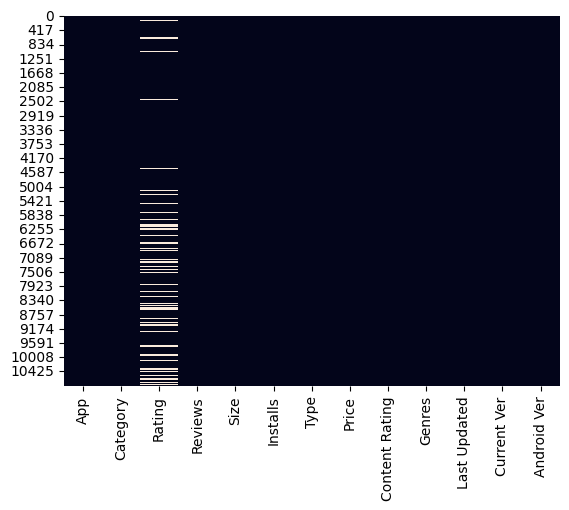

In [88]:
# Visualizing the missing values
sns.heatmap(data=df.isnull(), cbar=False)

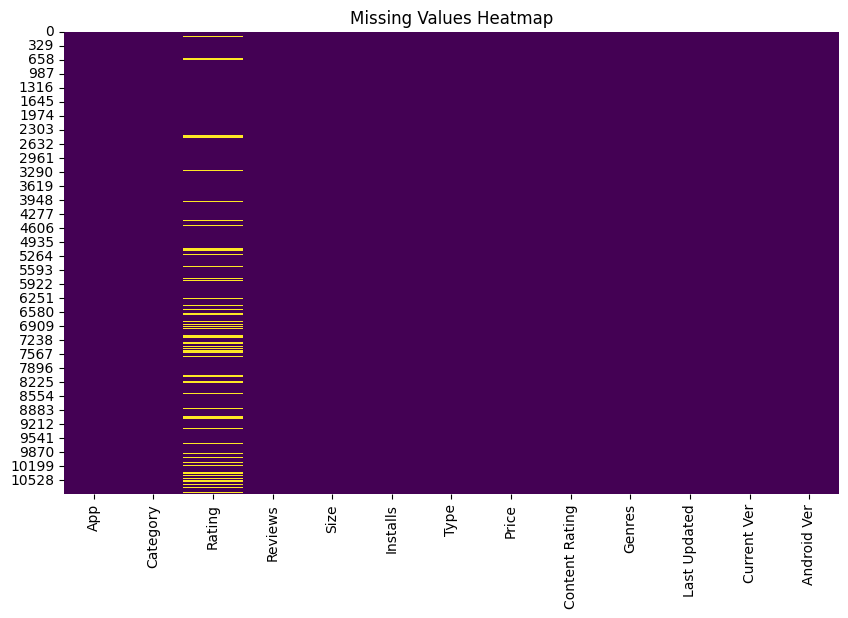

In [89]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

There are 483 out of 10841 duplicates rows in the dataset and there are null values mostly in the Rating Column.

## ***2. Understanding Your Variables***

In [90]:
# Dataset Columns
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [91]:
# Dataset Describe
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [92]:
df[df['Rating'] > 5].index

Index([10472], dtype='int64')

In [93]:
df.drop(df[df['Rating'] > 5].index, inplace=True)

In [94]:
df[df['Rating'] > 5].index

Index([], dtype='int64')

### Variables Description

We have 13 variables in which 'Rating' is a float type and all the other variables are object type

### Check Unique Values for each variable.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  object 
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.2+ MB


In [96]:
# Check Unique Values for each variable.
df['App'].unique()

array(['Photo Editor & Candy Camera & Grid & ScrapBook',
       'Coloring book moana',
       'U Launcher Lite – FREE Live Cool Themes, Hide Apps', ...,
       'Parkinson Exercices FR', 'The SCP Foundation DB fr nn5n',
       'iHoroscope - 2018 Daily Horoscope & Astrology'],
      shape=(9659,), dtype=object)

In [97]:
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

In [98]:
df['Rating'].unique()

array([4.1, 3.9, 4.7, 4.5, 4.3, 4.4, 3.8, 4.2, 4.6, 3.2, 4. , nan, 4.8,
       4.9, 3.6, 3.7, 3.3, 3.4, 3.5, 3.1, 5. , 2.6, 3. , 1.9, 2.5, 2.8,
       2.7, 1. , 2.9, 2.3, 2.2, 1.7, 2. , 1.8, 2.4, 1.6, 2.1, 1.4, 1.5,
       1.2])

In [99]:
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6001,), dtype=object)

In [100]:
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [101]:
df[-df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [102]:
df['Reviews'] = df['Reviews'].astype(int)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


In [104]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [105]:
df['Size'] = df['Size'].str.replace('M','000')
df['Size'] = df['Size'].str.replace('k','')
df['Size'] = df['Size'].replace('Varies with device',np.nan)
df['Size'] = df['Size'].astype(float)

In [106]:
df['Size'].unique()

array([1.90e+04, 1.40e+04, 8.70e+00, 2.50e+04, 2.80e+00, 5.60e+00,
       2.90e+04, 3.30e+04, 3.10e+00, 2.80e+04, 1.20e+04, 2.00e+04,
       2.10e+04, 3.70e+04, 2.70e+00, 5.50e+00, 1.70e+04, 3.90e+04,
       3.10e+04, 4.20e+00, 7.00e+00, 2.30e+04, 6.00e+00, 6.10e+00,
       4.60e+00, 9.20e+00, 5.20e+00, 1.10e+04, 2.40e+04,      nan,
       9.40e+00, 1.50e+04, 1.00e+04, 1.20e+00, 2.60e+04, 8.00e+00,
       7.90e+00, 5.60e+04, 5.70e+04, 3.50e+04, 5.40e+04, 2.01e+02,
       3.60e+00, 5.70e+00, 8.60e+00, 2.40e+00, 2.70e+04, 2.50e+00,
       1.60e+04, 3.40e+00, 8.90e+00, 3.90e+00, 2.90e+00, 3.80e+04,
       3.20e+04, 5.40e+00, 1.80e+04, 1.10e+00, 2.20e+00, 4.50e+00,
       9.80e+00, 5.20e+04, 9.00e+00, 6.70e+00, 3.00e+04, 2.60e+00,
       7.10e+00, 3.70e+00, 2.20e+04, 7.40e+00, 6.40e+00, 3.20e+00,
       8.20e+00, 9.90e+00, 4.90e+00, 9.50e+00, 5.00e+00, 5.90e+00,
       1.30e+04, 7.30e+04, 6.80e+00, 3.50e+00, 4.00e+00, 2.30e+00,
       7.20e+00, 2.10e+00, 4.20e+04, 7.30e+00, 9.10e+00, 5.50e

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.2+ MB


In [108]:
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [109]:
df['Installs'] = df['Installs'].str.replace(',','')
df['Installs'] = df['Installs'].str.replace('+','')

In [110]:
df['Installs'].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [111]:
df['Installs'] = df['Installs'].astype(int)

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 1.2+ MB


In [113]:
df['Type'].unique()

array(['Free', 'Paid', nan], dtype=object)

In [114]:
df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [115]:
df['Price'] = df['Price'].str.replace('$','')

In [116]:
df['Price'].unique()

array(['0', '4.99', '3.99', '6.99', '1.49', '2.99', '7.99', '5.99',
       '3.49', '1.99', '9.99', '7.49', '0.99', '9.00', '5.49', '10.00',
       '24.99', '11.99', '79.99', '16.99', '14.99', '1.00', '29.99',
       '12.99', '2.49', '10.99', '1.50', '19.99', '15.99', '33.99',
       '74.99', '39.99', '3.95', '4.49', '1.70', '8.99', '2.00', '3.88',
       '25.99', '399.99', '17.99', '400.00', '3.02', '1.76', '4.84',
       '4.77', '1.61', '2.50', '1.59', '6.49', '1.29', '5.00', '13.99',
       '299.99', '379.99', '37.99', '18.99', '389.99', '19.90', '8.49',
       '1.75', '14.00', '4.85', '46.99', '109.99', '154.99', '3.08',
       '2.59', '4.80', '1.96', '19.40', '3.90', '4.59', '15.46', '3.04',
       '4.29', '2.60', '3.28', '4.60', '28.99', '2.95', '2.90', '1.97',
       '200.00', '89.99', '2.56', '30.99', '3.61', '394.99', '1.26',
       '1.20', '1.04'], dtype=object)

In [117]:
## We can also apply loop to clean or remove or replace items in the DataFram from multiple columns in one time.

#char_to_remove = ['+',',','$']
#col_to_clean = ['Installs','price']
#for item in char_to remove:
    #for col in col_to_clean:
        #df[col] = df[col].str.replace(item,'')

In [118]:
df['Price'] = df['Price'].astype(float)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.2+ MB


In [120]:
df['Content Rating'].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [121]:
df['Genres'].unique()

array(['Art & Design', 'Art & Design;Pretend Play',
       'Art & Design;Creativity', 'Art & Design;Action & Adventure',
       'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Comics;Creativity', 'Communication', 'Dating',
       'Education;Education', 'Education', 'Education;Creativity',
       'Education;Music & Video', 'Education;Action & Adventure',
       'Education;Pretend Play', 'Education;Brain Games', 'Entertainment',
       'Entertainment;Music & Video', 'Entertainment;Brain Games',
       'Entertainment;Creativity', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Lifestyle;Pretend Play',
       'Adventure;Action & Adventure', 'Arcade', 'Casual', 'Card',
       'Casual;Pretend Play', 'Action', 'Strategy', 'Puzzle', 'Sports',
       'Music', 'Word', 'Racing', 'Casual;Creativity',
       'Casual;Action & Adventure', 'Simulation', 'Adventure', 'Board',
       'Trivia', 'Role 

In [122]:
df['Last Updated'].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      shape=(1377,), dtype=object)

In [123]:
pd.to_datetime(df['Last Updated'])

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10836   2017-07-25
10837   2018-07-06
10838   2017-01-20
10839   2015-01-19
10840   2018-07-25
Name: Last Updated, Length: 10840, dtype: datetime64[ns]

In [124]:
df['Last_Updated'] = pd.to_datetime(df['Last Updated'])
#df['Day'] = df['Last Updated'].dt.day                # We can add ccolumns like this also
#df['Month'] = df['Last Updated'].dt.month
#df['Year'] = df['Last Updated'].dt.year

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  object        
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Last_Updated    10840 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(8)
memor

In [126]:
df['Current Ver'].unique()

array(['1.0.0', '2.0.0', '1.2.4', ..., '1.0.612928', '0.3.4', '2.0.148.0'],
      shape=(2832,), dtype=object)

In [127]:
df['Android Ver'].unique()

array(['4.0.3 and up', '4.2 and up', '4.4 and up', '2.3 and up',
       '3.0 and up', '4.1 and up', '4.0 and up', '2.3.3 and up',
       'Varies with device', '2.2 and up', '5.0 and up', '6.0 and up',
       '1.6 and up', '1.5 and up', '2.1 and up', '7.0 and up',
       '5.1 and up', '4.3 and up', '4.0.3 - 7.1.1', '2.0 and up',
       '3.2 and up', '4.4W and up', '7.1 and up', '7.0 - 7.1.1',
       '8.0 and up', '5.0 - 8.0', '3.1 and up', '2.0.1 and up',
       '4.1 - 7.1.1', nan, '5.0 - 6.0', '1.0 and up', '2.2 - 7.1.1',
       '5.0 - 7.1.1'], dtype=object)

In [128]:
df[df.duplicated('App')].shape

(1181, 14)

In [129]:
df = df.drop_duplicates(subset=['App'],keep='first')

In [130]:
df[df.duplicated('App')].shape

(0, 14)

In [131]:
df.shape

(9659, 14)

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          8196 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            8432 non-null   float64       
 5   Installs        9659 non-null   int64         
 6   Type            9658 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   object        
 11  Current Ver     9651 non-null   object        
 12  Android Ver     9657 non-null   object        
 13  Last_Updated    9659 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(8)
memory

In [133]:
# Write your code to make your dataset analysis ready.

### What all manipulations have you done and insights you found?

There were some process done to clean the data:
- Removed the meaningless rows
- Removed duplicate rows
- Changes the data type of columns if needed
- Removed or Replaced unwanted signs in the columns

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

In [134]:
numerical_col = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_col = [feature for feature in df.columns if df[feature].dtype == 'O']

print(f'There are {len(numerical_col)} numerical feature columns: {numerical_col}')
print(f'There are {len(categorical_col)} categorical feature columns: {categorical_col}')

There are 6 numerical feature columns: ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last_Updated']
There are 8 categorical feature columns: ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


## 1. Univariate Analysis (Charts 1–6)

#### Chart - 1

In [135]:
# Chart - 1 visualization code:                       # We can also create DataFrame of App categories and App count based on categories
# Top 10 App Categories by app count:

#category = pd.DataFrame(df['Category'].value_counts())
#category.rename(columns={'Category','App count'},inplace=True)

In [136]:
#plt.figure(figsize=(15,6))
#sns.barplot(x=category.index[:10], y='count', data = category[:10],palette='hls')
#plt.title('Top 10 App Category')
#plt.xticks(rotation=90)
#plt.show()

C:\Users\shamm\AppData\Local\Temp\ipykernel_27972\2751188539.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis',)


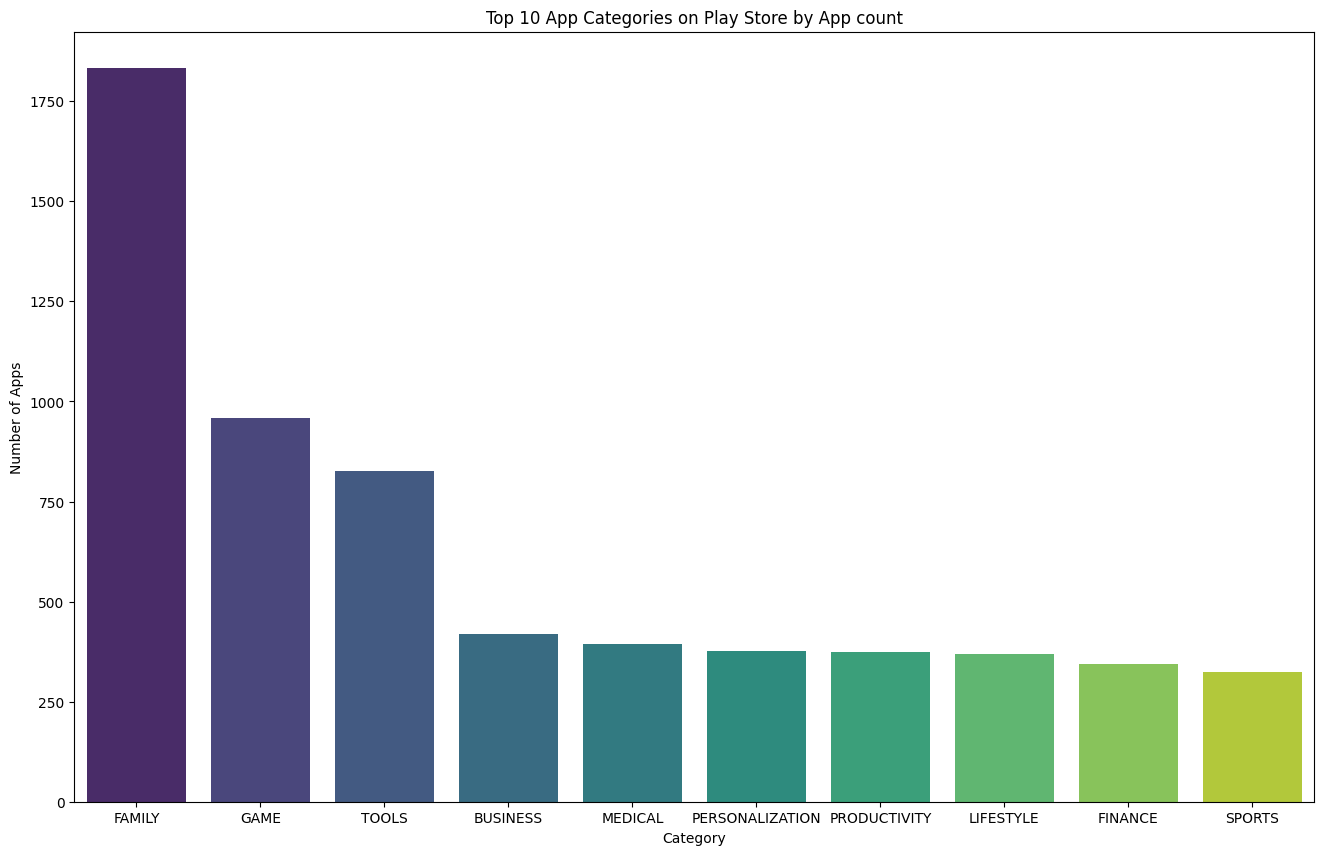

In [137]:
# 2nd method
# Chart - 1 visualization code
# Top 10 App Categories by app count:
plt.figure(figsize=(16,10))

top_categories = df['Category'].value_counts().head(10)

sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis',)
plt.title('Top 10 App Categories on Play Store by App count')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.show()

##### 1. Why did you pick the specific chart?

Here we used Barplot to show the relationship between category that is categorical variable and value counts of app based on category that is 'number of apps' which is numerical variable.

##### 2. What is/are the insight(s) found from the chart?

The category 'Family' having highest number of App

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, top three App categories are Family,Game and Tools, which shows these category apps having more demand.

Whe we go through the least number of app category we have Sports,Finance etc having less apps than other cateogry.But it is an oppertunity to craete good apps based on these category can gain popularity because we have less number of apps available.

It can lead to negative impact if we create apps in the category with highest number off apps. Because there is already many options to the users.

#### Chart - 2

<Axes: xlabel='Rating', ylabel='Count'>

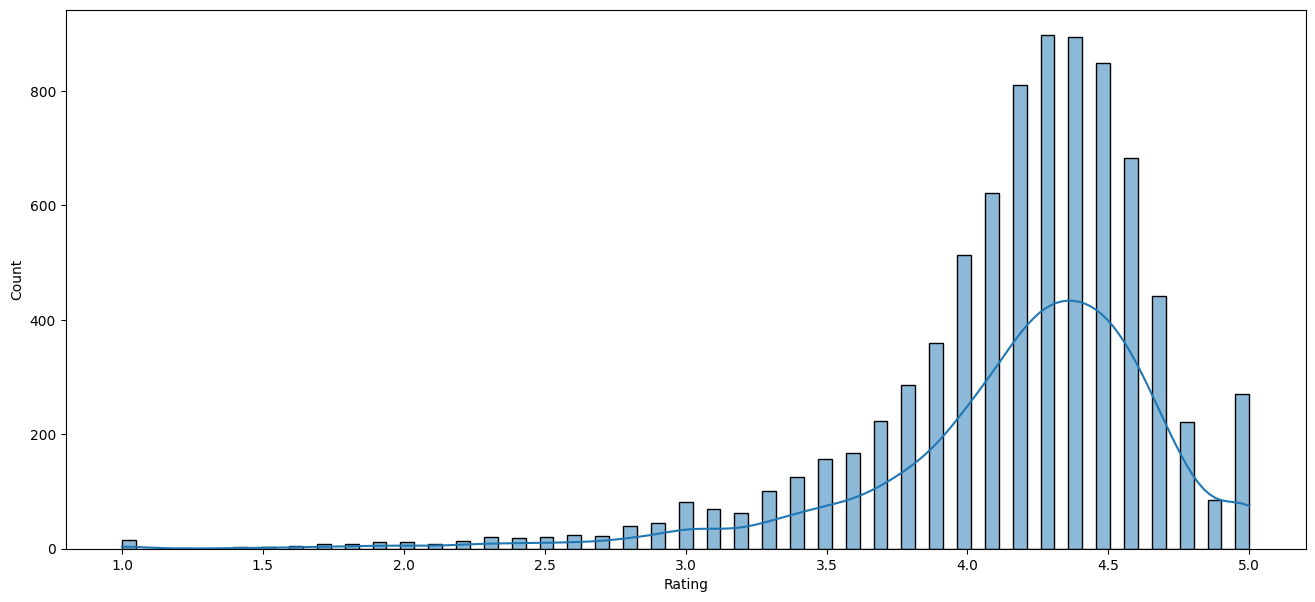

In [138]:
# Chart - 2 visualization code
# Distribution of App Ratings:

plt.figure(figsize=(16,7))

sns.histplot(data=df , x='Rating',kde=True)

##### 1. Why did you pick the specific chart?

In this Histogram , It shows the Rating distribution of Apps

##### 2. What is/are the insight(s) found from the chart?

It shows which number of rating is higher and it shows 4.3 is higher.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It shows the positive impact that majority of apps have good ratings.

No.

#### Chart - 3

<Axes: ylabel='count'>

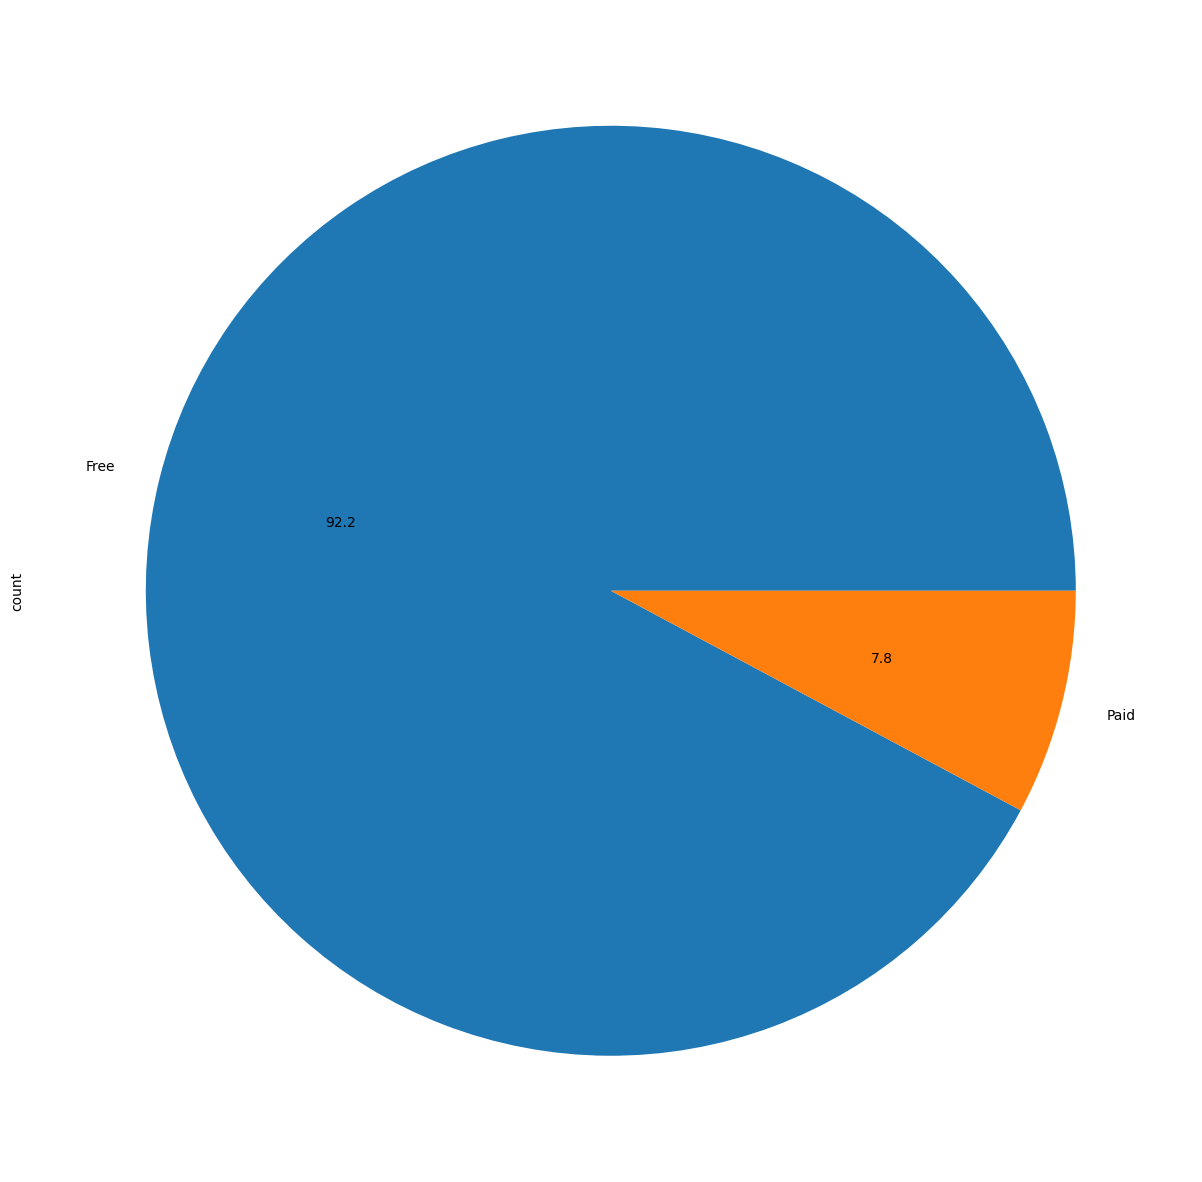

In [139]:
# Chart - 3 visualization code
#Proportion of Free vs. Paid Apps

df['Type'].value_counts().plot.pie(x=df['Type'],figsize=(15,16),autopct='%1.1f')

##### 1. Why did you pick the specific chart?

Thia pie chart is easy to understand

##### 2. What is/are the insight(s) found from the chart?

We got percentage of free apps and paid apps, in which 92.2% apps are free and 7.8% apps are paid.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, there are most of the apps are free, which can attract the users.

yes, free apps can have issuse to sustain and being in the market and it can have quality and service issue but Paid apps may have better quality and better services than free apps.

#### Chart - 4

Text(0.5, 1.0, 'Distribution of Sizes')

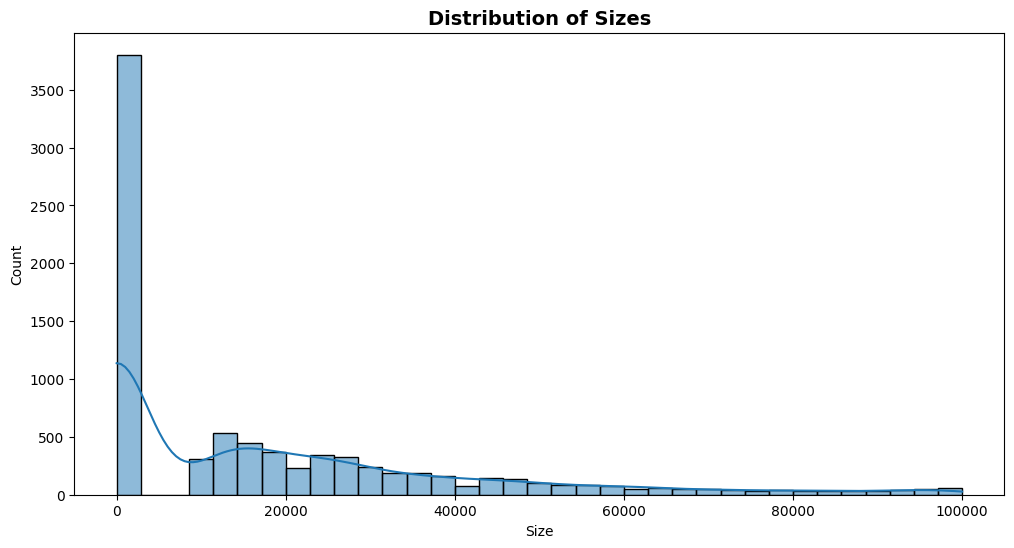

In [140]:
# Chart - 4 visualization code
# Distribution of app Sizes

plt.figure(figsize=(12,6))

sns.histplot(df['Size'].dropna(),bins=35,kde=True)
plt.title('Distribution of Sizes',fontsize=14,fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

It shows the distribution of App sizes

##### 2. What is/are the insight(s) found from the chart?

The chart is right skewed, it shows majority of apps clustered heavely on the lower end that is close to 0 on the x-axis.

More than 35000 apps have a very small file size

As the size increase past 20000 KB, the count drops off significantly but stretches all the way out to 100000 KB

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Less size of apps are present in large number rhat will be good for user to occupy less space in the devices.

Less size apps can have less features that would impact on the services ao apps

#### Chart - 5

C:\Users\shamm\AppData\Local\Temp\ipykernel_27972\2635783529.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= content_counts.index , y=content_counts.values, palette='plasma')


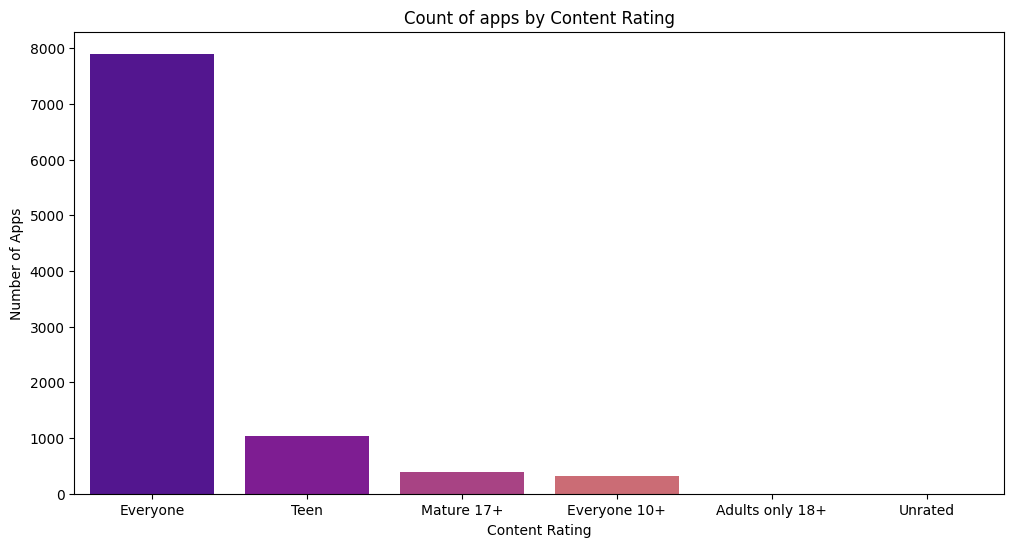

In [141]:
# Chart - 5 visualization code
# Count of apps by Content Rating (Everyone, Teen, Mature)

plt.figure(figsize=(12,6))
content_counts = df['Content Rating'].value_counts()

sns.barplot(x= content_counts.index , y=content_counts.values, palette='plasma')
plt.title('Count of apps by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.show()

##### 1. Why did you pick the specific chart?

This barplot shows the count of apps by content rating

##### 2. What is/are the insight(s) found from the chart?

Majority of apps is rated by Everyone

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This shows Content rating is given by Everyone is higher than other age groups

No

#### Chart - 6

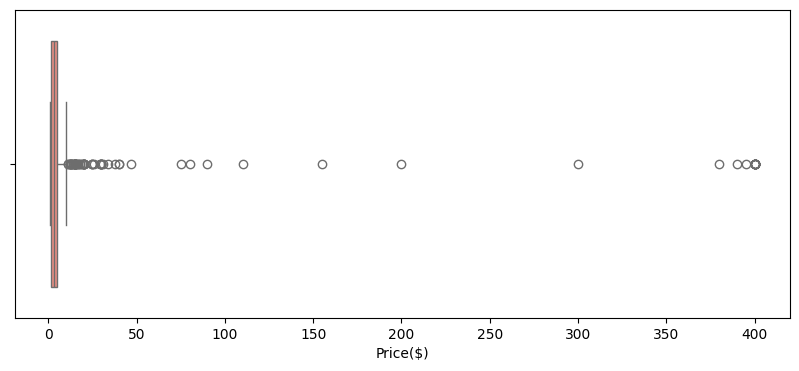

In [142]:
# Chart - 6 visualization code
# Checking for outliers in app Prices.

plt.figure(figsize=(10,4))
app_price = df[df['Price'] > 0]
sns.boxplot(x=app_price['Price'], color='salmon')
plt.xlabel('Box Plot of Paid App Prices (Outlier Detection)')
plt.xlabel('Price($)')
plt.show()

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          8196 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            8432 non-null   float64       
 5   Installs        9659 non-null   int64         
 6   Type            9658 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   object        
 11  Current Ver     9651 non-null   object        
 12  Android Ver     9657 non-null   object        
 13  Last_Updated    9659 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(8)
memory

##### 1. Why did you pick the specific chart?

This Box plot shows outliers in app Prices for paid apps

##### 2. What is/are the insight(s) found from the chart?

Most of the paid apps are priced under $10 but there are also extreme outlier apps priced up to $400

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

yes, it shows the acceptable price for users is low.

Pricing beond $10 without an extraordinary enterprice justification will lead to zero installs.

#### Chart - 7

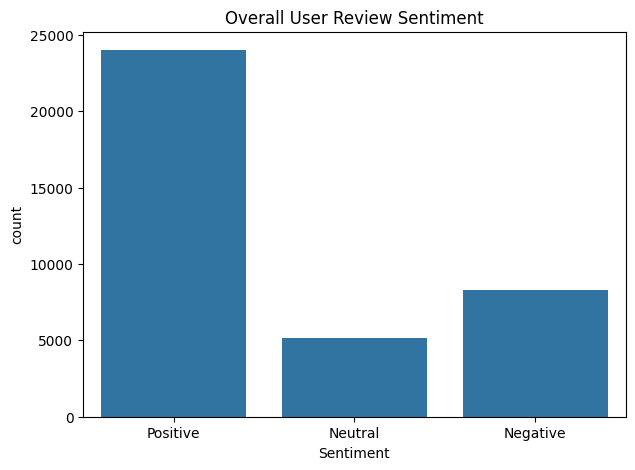

In [144]:
# Chart - 7 visualization code
# Sentiment Breakdown of User Reviews

plt.figure(figsize=(7,5))

sns.countplot(data= df2, x='Sentiment',order=['Positive','Neutral','Negative'])
plt.title('Overall User Review Sentiment')
plt.show()

In [145]:
df2.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


##### 1. Why did you pick the specific chart?

To show the Sentiment Breakdown of User Reviews

##### 2. What is/are the insight(s) found from the chart?

Most of the reviews are positive

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The posituive reviews can encurage the developers to create quality apps.
Negative reviews can be example for developers to evaluate the apps.

## 2. Bivariate Analysis (Charts 8–15)

#### Chart - 8

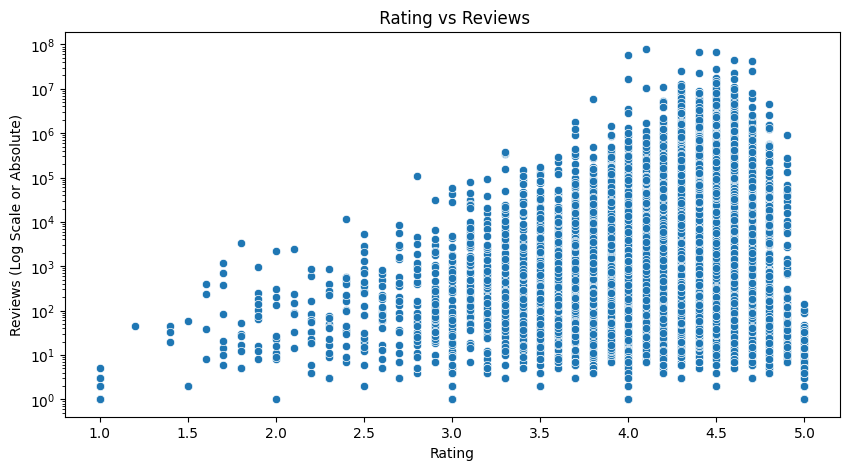

In [146]:
# Chart - 8 visualization code
# Rating vs. Reviews:

plt.figure(figsize=(10,5))

sns.scatterplot(data=df, x=df['Rating'], y=df['Reviews'])
plt.title(' Rating vs Reviews')
plt.xlabel('Rating')
plt.ylabel('Reviews (Log Scale or Absolute)')

plt.yscale('log')

##### 1. Why did you pick the specific chart?

To see apps with massive review counts tend to converge toward specific rating thresholds (It means as the number of reviews increases, an app's average rating becomes more stable and tends to fall within a limited range instead of being extremely high or low.)

##### 2. What is/are the insight(s) found from the chart?

As the number of reviews increases, an app's average rating becomes more stable and tends to fall within a limited range instead of being extremely high or low.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Higher number of the Reviews means more stable the Rating

If there is less number of Reviews then It is difficult to say Rating is better, if there are 5 Reviews and all gives 5 star rating then the overall rating will be 5.Then we have less information to evaluate the app

#### Chart - 9

C:\Users\shamm\AppData\Local\Temp\ipykernel_27972\1356260535.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_rating, x='Category',y='Rating',palette='plasma')


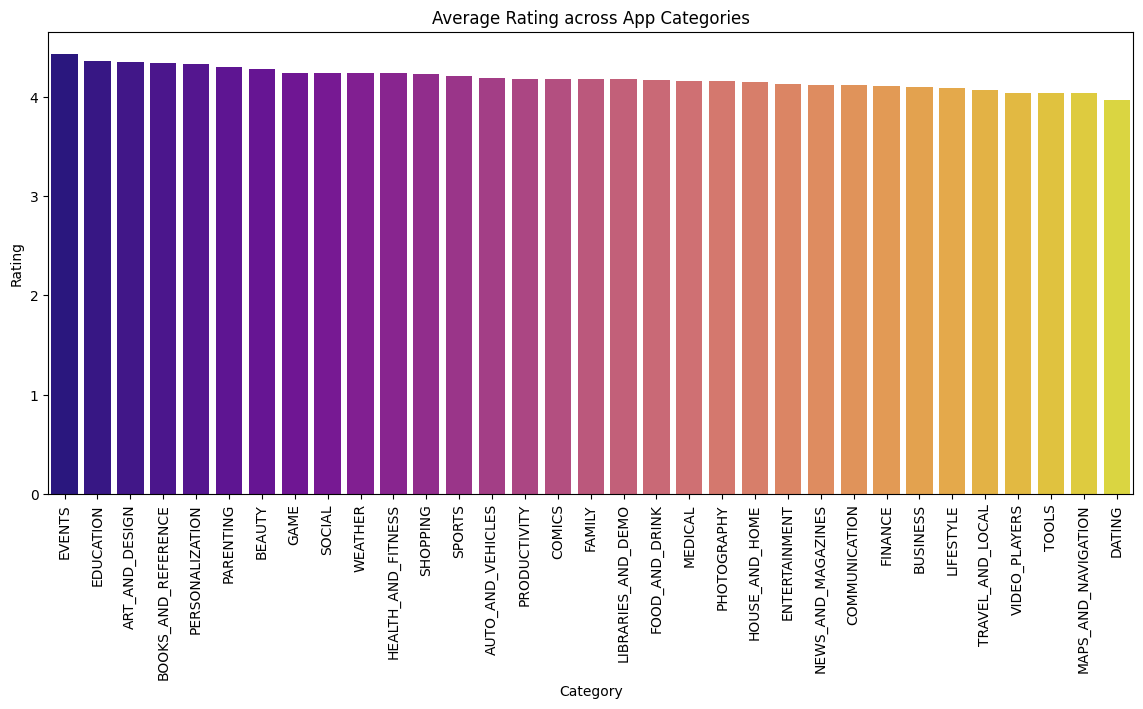

In [147]:
# Chart - 9 visualization code
# Average rating by Category

plt.figure(figsize=(14,6))

category_rating= df.groupby('Category')['Rating'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=category_rating, x='Category',y='Rating',palette='plasma')
plt.xticks(rotation=90)
plt.title('Average Rating across App Categories')
plt.show()

In [148]:
category_rating

,Category,Rating
0,EVENTS,4.435556
1,EDUCATION,4.364407
2,ART_AND_DESIGN,4.357377
3,BOOKS_AND_REFERENCE,4.344970
4,PERSONALIZATION,4.332215
5,PARENTING,4.300000
6,BEAUTY,4.278571
7,GAME,4.247368
8,SOCIAL,4.247291
9,WEATHER,4.243056


##### 1. Why did you pick the specific chart?

To check which categories consistently satisfy their users

##### 2. What is/are the insight(s) found from the chart?

It shows which category apps have ratings higher or lower

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Education,events,weather and ART_AND_DESIGHN have better ratings than others

#### Chart - 10

C:\Users\shamm\AppData\Local\Temp\ipykernel_27972\71433693.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=installs_per_category, x='Category',y='Installs',palette='plasma')


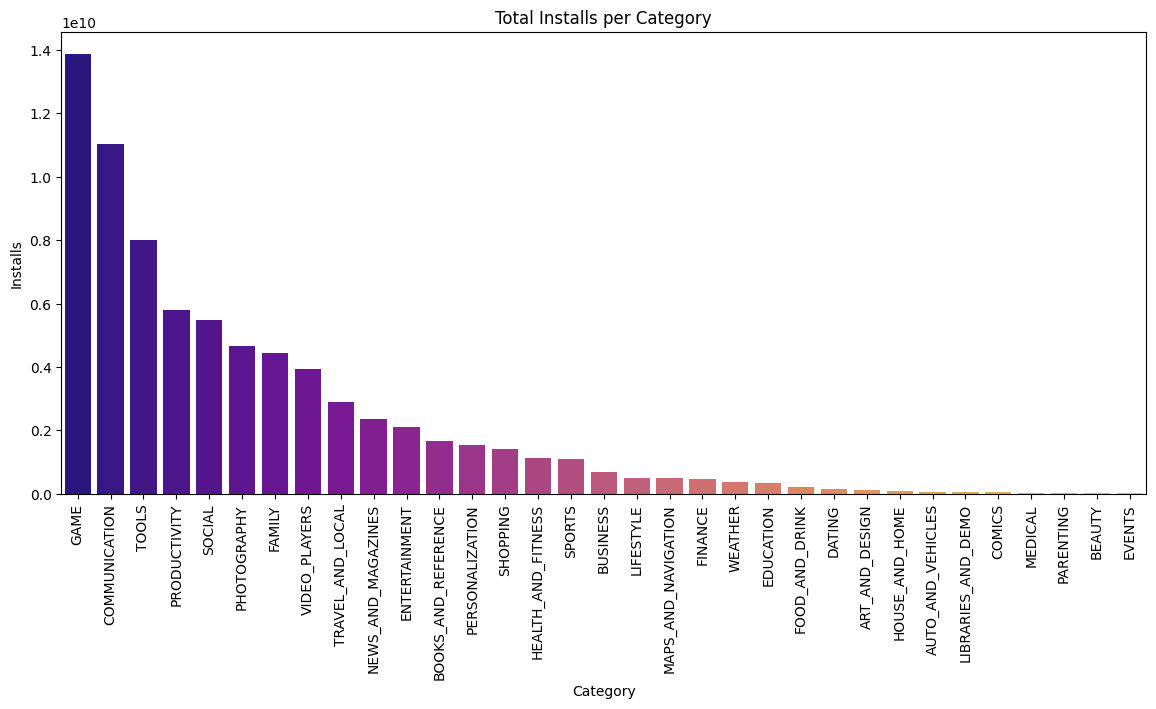

In [149]:
# Chart - 10 visualization code
# Total installs per Category
plt.figure(figsize=(14,6))

installs_per_category = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=installs_per_category, x='Category',y='Installs',palette='plasma')
plt.xticks(rotation=90)
plt.title('Total Installs per Category')
plt.show()

##### 1. Why did you pick the specific chart?

I used Barplot to show Total installs per Category

##### 2. What is/are the insight(s) found from the chart?

Categories like Game,Communication,Tools,Productivity,Social are on top five that get highest installs

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It shows Game Category got highest installs that means large number of users are interested in gaming, that would be an oppertunity for the developpers.

Events,Beauty,Parenting etc got low number of downloads that is not better Category to develop into.

#### Chart - 11

C:\Users\shamm\AppData\Local\Temp\ipykernel_27972\2776199671.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x= 'Size', y='Installs', palette='plasma')


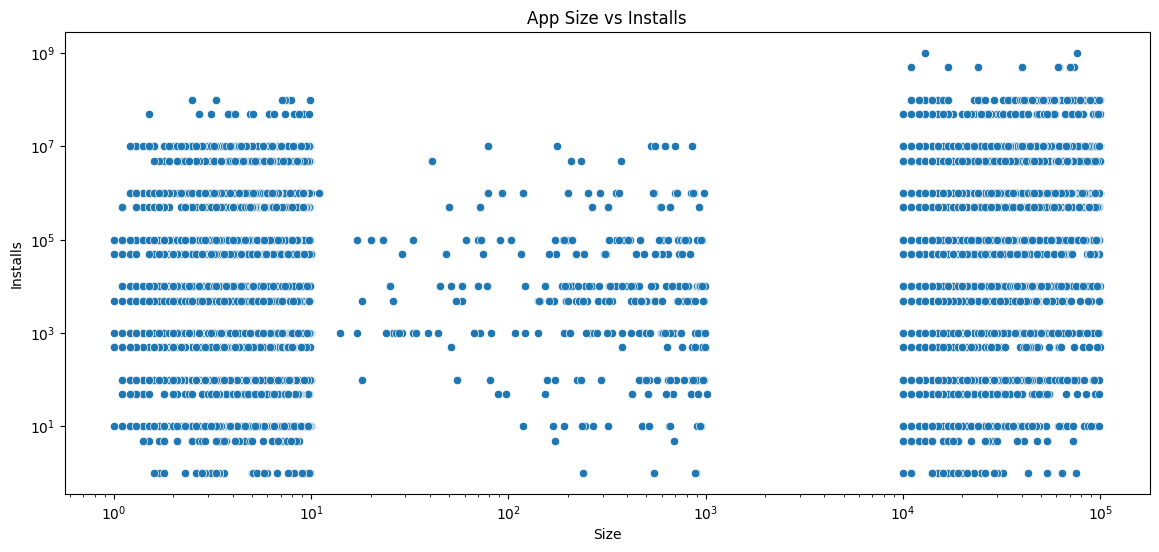

In [150]:
# Chart - 11 visualization code
# App Size vs Installs:

plt.figure(figsize=(14,6))

sns.scatterplot(data=df, x= 'Size', y='Installs', palette='plasma')
plt.xscale('log')
plt.yscale('log')
plt.title('App Size vs Installs')
plt.show()

##### 1. Why did you pick the specific chart?

To analyze if heavier app sizes act as a barrier to entry for user installs

##### 2. What is/are the insight(s) found from the chart?

App bloat negatively impacts total download velocity. Optimization directly pays off in higher installations

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Smaller, optimized apps may attract more users, especially those with limited storage or slower internet.

Very large app sizes may discourage users from downloading due to higher storage and data requirements, which can reduce install rates and limit growth.

#### Chart - 12

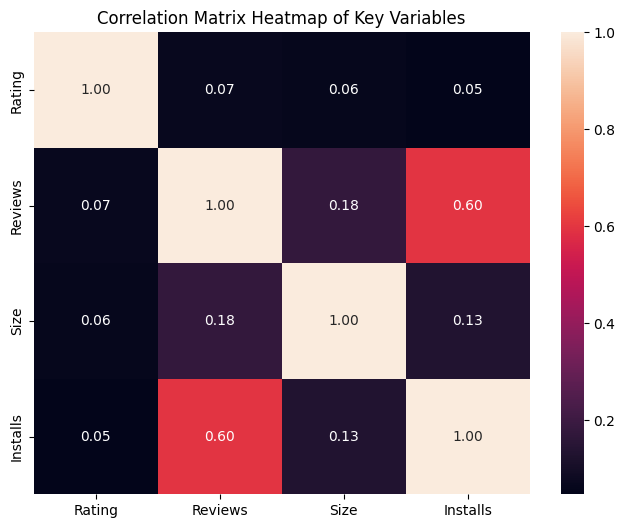

In [152]:
# Chart - 12 visualization code
# Correlation Matrix Heatmap

plt.figure(figsize=(8,6))

numerical_df= df[['Rating','Reviews','Size','Installs']].dropna()

sns.heatmap(data= numerical_df.corr(), annot=True, fmt='.2f')
plt.title('Correlation Matrix Heatmap of Key Variables')
plt.show()

##### 1. Why did you pick the specific chart?

Matrix heatmap visually organizes correlation variables using color-coded grids to quickly flag statistical relationships

##### 2. What is/are the insight(s) found from the chart?

Reviews and Installs feature a very strong positive correlation coefficient. Size tracks minor positive impacts on installs, while baseline Rating metrics demonstrate weak direct mathematical correlation with basic dimension growth.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Validates that optimizing review accumulation directly correlates with growth in total installations.

Shows that simply having a high rating doesn't automatically guarantee high install numbers; a solid marketing and user acquisition strategy is still required.

#### Chart - 13

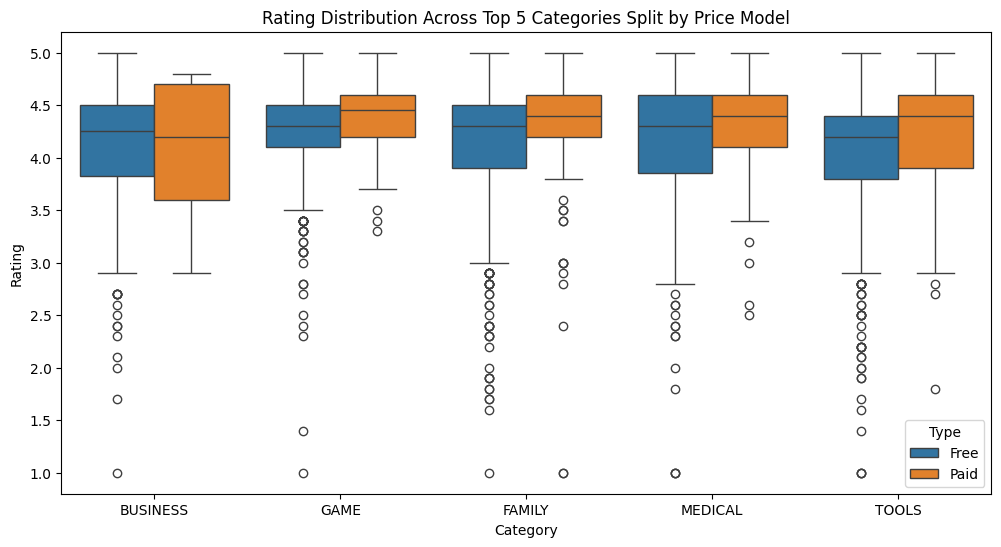

In [178]:
# Chart - 13 visualization code
# Pricing Model Dynamics Across Top Categories:
top_5_cats = df['Category'].value_counts().head(5).index
filtered_df = df[df['Category'].isin(top_5_cats)]

plt.figure(figsize=(12,6))
sns.boxplot(data= filtered_df, x='Category', y='Rating', hue='Type')
plt.title('Rating Distribution Across Top 5 Categories Split by Price Model')
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot analyzes interactions between multiple variables at once: category classifications, numerical ratings, and free vs. paid pricing models.

##### 2. What is/are the insight(s) found from the chart?

Paid variants across major categories like GAME and FAMILY frequently exhibit tighter, higher median evaluation distributions than free ones. Paid options cut out low-tier rating noise.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Demonstrates that if a premium monetization strategy is chosen, users will expect a premium experience. When delivered, this can result in higher, more stable ratings.



## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the EDA, the following recommendations can help achieve the business objective:

1. **Target under-served, high-engagement categories:** Categories like Game, Communication, Tools, Productivity, and Social drive the highest installs, but Family, Game, and Tools are also the most saturated by app count. Categories such as Events, Beauty, and Parenting have fewer apps and lower installs today, which can represent lower-competition opportunities for a well-executed app, while Education, Weather, and Art & Design stand out for consistently higher user ratings.
2. **Optimize app size:** Since larger app sizes are associated with fewer installs, keeping the app as lightweight as possible (especially for markets with storage or bandwidth constraints) can reduce friction and improve download conversion.
3. **Prioritize review volume, not just rating:** Because installs correlate much more strongly with review count than with rating alone, a strategy that encourages users to leave reviews (in-app prompts, responsive support, etc.) is likely to have a bigger impact on visibility and installs than chasing a marginally higher star rating.
4. **Be deliberate about pricing:** Most successful paid apps are priced under $10, and paid apps in top categories showed tighter, slightly higher rating distributions than free ones. A paid or freemium model should be reserved for cases where the app can clearly justify a premium experience; pricing far beyond $10 without strong differentiation is likely to suppress installs.
5. **Monitor sentiment, not just star ratings:** Since the majority of reviews are positive but a meaningful share are neutral/negative, tracking review sentiment over time can act as an early warning system for quality or support issues before they show up in the aggregate star rating.

# **Conclusion**

This EDA of the Google Play Store dataset shows that app success is shaped by a combination of category choice, app size, and user engagement (review volume) more than by rating alone. After cleaning duplicates, invalid values, and inconsistent data types, the analysis revealed that installs are concentrated in a small set of categories (Game, Communication, Tools, Productivity, Social), that smaller app sizes correlate with higher installs, and that review count is a much stronger predictor of installs than star rating. Free apps dominate the store (92.2%), and among paid apps, prices cluster below $10, with paid apps often showing slightly more consistent (and higher) ratings than free ones in top categories. User review sentiment skews strongly positive, reinforcing that overall app quality on the platform is generally well-received by users.

Together, these findings offer a practical, data-driven playbook: choose categories with strong demand but manageable competition, keep the app lightweight, invest in driving genuine user reviews, and set pricing thoughtfully rather than aggressively. Future work could extend this analysis with time-series trends (using the Last Updated field), NLP-based topic modeling of negative reviews to pinpoint specific pain points, or a predictive model to estimate expected installs for a new app based on its planned category, size, and pricing.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***